<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter04_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


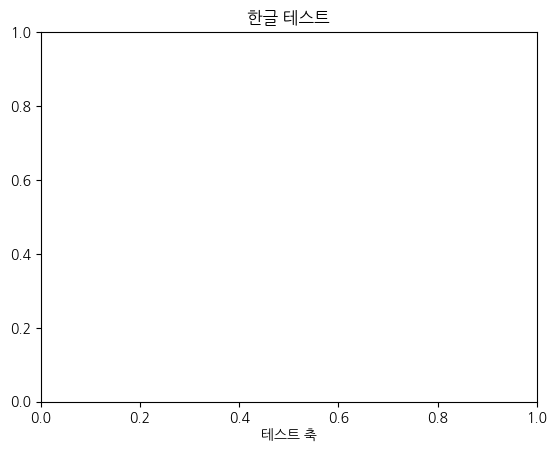

In [1]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#사이킷런 유방암 데이터셋
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import( #평가 지표
    confusion_matrix, accuracy_score,
    precision_score, recall_score,
    f1_score, roc_auc_score
)

dataset = load_breast_cancer()
cancer_df = pd.DataFrame(
    data = dataset.data,
    columns = dataset.feature_names
)
cancer_df['target'] = dataset.target

#독립변수(X)와 종속변수(y) 분리
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

#전체 데이터셋을 학습(80%)과 테스트(20%) 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label,
    test_size = 0.2,
    random_state = 156 #데이터 분할의 재현성을 위해 랜던 시드 고정
)
#학습셋(X_train, y_train)을 다시 학습(90%)과 검증(10%) 세트로 분할
#검증셋은 Early Stopping 모니터링에만 사용되며(학습에서는 사용X), 최종 성능 평가는 테스트셋으로 진행
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=156
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('X_tr:', X_tr.shape, '| X_val:', X_val.shape)

X_train: (455, 30) | X_test: (114, 30)
X_tr: (409, 30) | X_val: (46, 30)


In [3]:
#통합 평가 함수
def get_clf_eval(y_test, pred=None, pred_proba=None, model_name=''):
  confusion = confusion_matrix(y_test, pred) #오차 행렬 계산
  accuracy = accuracy_score(y_test, pred) #정확도 계산
  precision = precision_score(y_test, pred) #정밀도 계산
  recall = recall_score(y_test, pred) #재현율 계산
  f1 = f1_score(y_test, pred) #F1 스토어 계산
  roc_auc = roc_auc_score(y_test, pred_proba) #ROC-AUC 스코어 계산

  title = f'=== {model_name} ===' if model_name else '=== 모델 성능 ==='
  print(title)
  print('오차 행렬')
  print(confusion)
  print(
      f'정확도:{accuracy:.4f} | 정밀도:{precision:.4f}|'
      f'재현율:{recall:.4f} | F1:{f1:.4f} | AUC:{roc_auc:.4f}'
  )

### XGBoost - 파이썬 래퍼(xgb.train)

In [4]:
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

#XGBoost 전용 데이터 구조
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

#주요 하이퍼파라미터
params = {
    'max_depth': 3, #개별 트리의 최대 깊이
    'eta': 0.05, #학습률(learning_rate)
    'objective':'binary:logistic', #모델이 최적화할 목적 함수:이진 분류:로지스틱 회귀의 손실 함수
    'eval_metric':'logloss' #평가 지표:logloss는 확률 예측의 정확도를 벌점화. 값이 낮을수록 좋음
}
num_rounds = 400 #최대 부스팅 라운드 수, 생성할 트리의 최대 개수

#학습 실행
eval_list = [(dtr,'train'),(dval,'eval')] #모니터링 리스트
xgb_model = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_rounds,
    early_stopping_rounds=50, #검증 성능 개선이 없는 최대 라운드 수
    evals=eval_list #학습 중 모니터링할 데이터셋 리스트
)
print(f'\n학습 완료, 최적 라운드: {xgb_model.best_iteration}')
print(f'최적 라운드의 검증 logloss: {xgb_model.best_score:.6f}')

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

In [5]:
#예측 및 평가
pred_probs = xgb_model.predict(dtest) #양성(1) 클래스 예측 확률값 배열 [음성0.2, 양성0.7]
print('예측 확률값 앞 10개:')
print(np.round(pred_probs[:10],3))

#임계값 0.5: 확률 ≥ 0.5 → 1(양성), < 0.5 → 0(음성)
preds = [1 if p > 0.5 else 0 for p in pred_probs]
print('예측 레이블 앞 10개:', preds[:10])

#최종 성능 평가
get_clf_eval(y_test, preds, pred_probs, 'XGBoost 파이썬 래퍼')

예측 확률값 앞 10개:
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측 레이블 앞 10개: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]
=== XGBoost 파이썬 래퍼 ===
오차 행렬
[[35  2]
 [ 2 75]]
정확도:0.9649 | 정밀도:0.9740|재현율:0.9740 | F1:0.9740 | AUC:0.9965


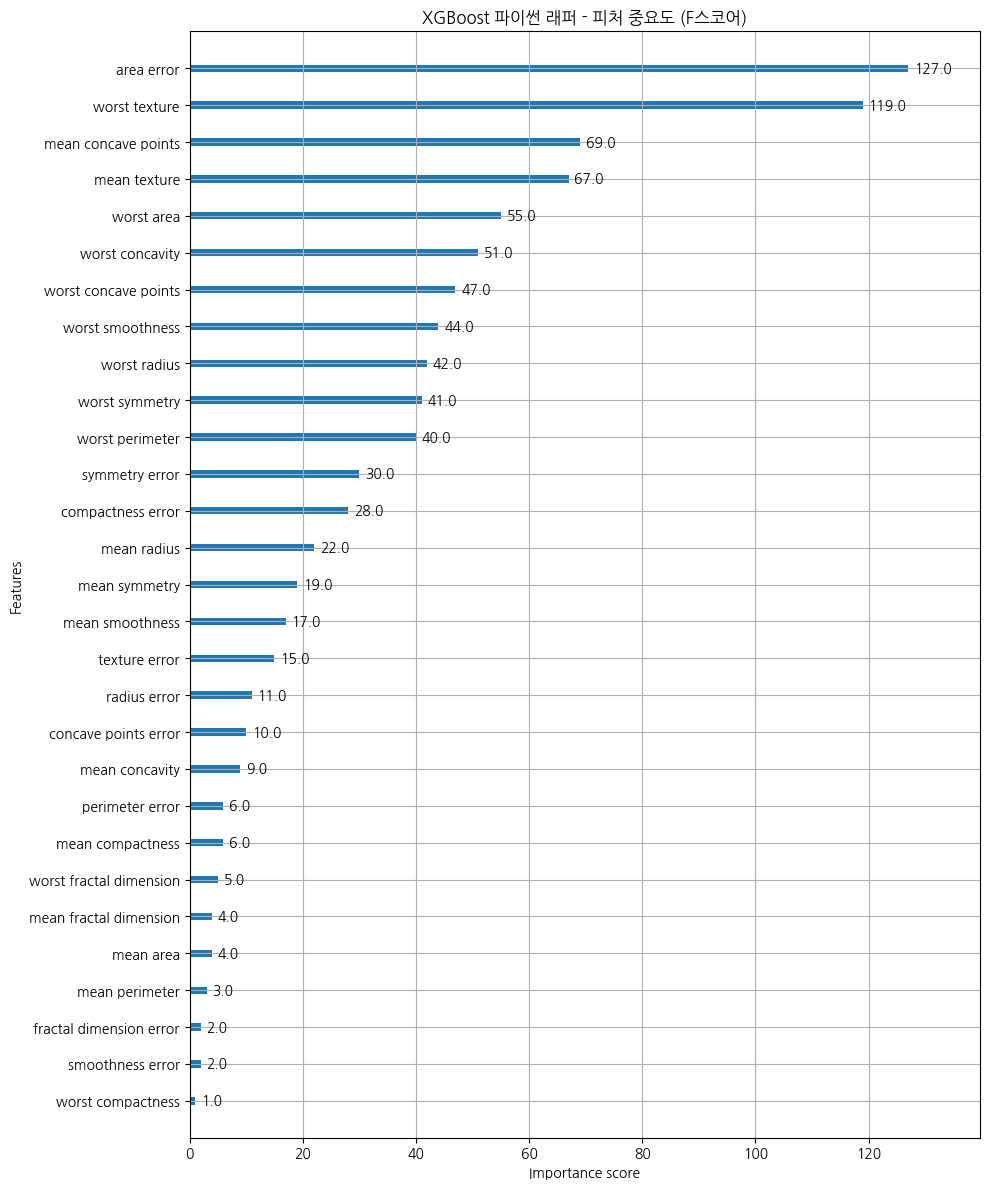

In [6]:
#피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)
plt.title('XGBoost 파이썬 래퍼 - 피처 중요도 (F스코어)')
plt.tight_layout()
plt.show()

### XGBoost - 사이킷런 래퍼(XGBClassifier)

In [7]:
from xgboost.sklearn import XGBClassifier
from xgboost.callback import EarlyStopping

xgb_wrapper1 = XGBClassifier( #최신 XGBoost 방식
    n_estimators=400, #부스팅 트리 수 (최대 라운드)
    learning_rate=0.1,
    max_depth = 3,
    eval_metric = 'logloss',
    random_state = 156,
    callbacks = [EarlyStopping(rounds=100,save_best=True,maximize=False)] #logloss는 낮을수록 좋으므로 False(minim)
)
#Early Stopping 모니터링
evals = [(X_tr,y_tr),(X_val,y_val)]

xgb_wrapper1.fit(X_tr,y_tr,eval_set=evals,verbose = True) #매 라운드 logloss 출력
w_preds = xgb_wrapper1.predict(X_test)
w_pred_proba = xgb_wrapper1.predict_proba(X_test)[:,1] #['음성 확률','양성 확률']

get_clf_eval(y_test,w_preds,w_pred_proba, 'XGBoost 사이킷래퍼(Early Stopping=100)')

[0]	validation_0-logloss:0.58448	validation_1-logloss:0.60406
[1]	validation_0-logloss:0.51755	validation_1-logloss:0.55810
[2]	validation_0-logloss:0.46160	validation_1-logloss:0.51829
[3]	validation_0-logloss:0.41227	validation_1-logloss:0.48332
[4]	validation_0-logloss:0.37097	validation_1-logloss:0.45158
[5]	validation_0-logloss:0.33550	validation_1-logloss:0.42452
[6]	validation_0-logloss:0.30431	validation_1-logloss:0.40638
[7]	validation_0-logloss:0.27728	validation_1-logloss:0.38845
[8]	validation_0-logloss:0.25301	validation_1-logloss:0.37252
[9]	validation_0-logloss:0.23069	validation_1-logloss:0.35833
[10]	validation_0-logloss:0.21102	validation_1-logloss:0.34634
[11]	validation_0-logloss:0.19422	validation_1-logloss:0.33539
[12]	validation_0-logloss:0.17862	validation_1-logloss:0.32481
[13]	validation_0-logloss:0.16474	validation_1-logloss:0.31769
[14]	validation_0-logloss:0.15249	validation_1-logloss:0.31101
[15]	validation_0-logloss:0.14137	validation_1-logloss:0.30528
[1

In [8]:
from xgboost.sklearn import XGBClassifier
from xgboost.callback import EarlyStopping

xgb_wrapper2 = XGBClassifier( #최신 XGBoost 방식
    n_estimators=400, #부스팅 트리 수 (최대 라운드)
    learning_rate=0.1,
    max_depth = 3,
    eval_metric = 'logloss',
    random_state = 156,
    callbacks = [EarlyStopping(rounds=10,save_best=True,maximize=False)] #logloss는 낮을수록 좋으므로 False(minim)
)
#Early Stopping 모니터링
evals = [(X_tr,y_tr),(X_val,y_val)]

xgb_wrapper2.fit(X_tr,y_tr,eval_set=evals,verbose = True) #매 라운드 logloss 출력
w_preds = xgb_wrapper2.predict(X_test)
w_pred_proba = xgb_wrapper2.predict_proba(X_test)[:,1] #['음성 확률','양성 확률']

get_clf_eval(y_test,w_preds,w_pred_proba, 'XGBoost 사이킷래퍼(Early Stopping=100)')

[0]	validation_0-logloss:0.58448	validation_1-logloss:0.60406
[1]	validation_0-logloss:0.51755	validation_1-logloss:0.55810
[2]	validation_0-logloss:0.46160	validation_1-logloss:0.51829
[3]	validation_0-logloss:0.41227	validation_1-logloss:0.48332
[4]	validation_0-logloss:0.37097	validation_1-logloss:0.45158
[5]	validation_0-logloss:0.33550	validation_1-logloss:0.42452
[6]	validation_0-logloss:0.30431	validation_1-logloss:0.40638
[7]	validation_0-logloss:0.27728	validation_1-logloss:0.38845
[8]	validation_0-logloss:0.25301	validation_1-logloss:0.37252
[9]	validation_0-logloss:0.23069	validation_1-logloss:0.35833
[10]	validation_0-logloss:0.21102	validation_1-logloss:0.34634
[11]	validation_0-logloss:0.19422	validation_1-logloss:0.33539
[12]	validation_0-logloss:0.17862	validation_1-logloss:0.32481
[13]	validation_0-logloss:0.16474	validation_1-logloss:0.31769
[14]	validation_0-logloss:0.15249	validation_1-logloss:0.31101
[15]	validation_0-logloss:0.14137	validation_1-logloss:0.30528
[1

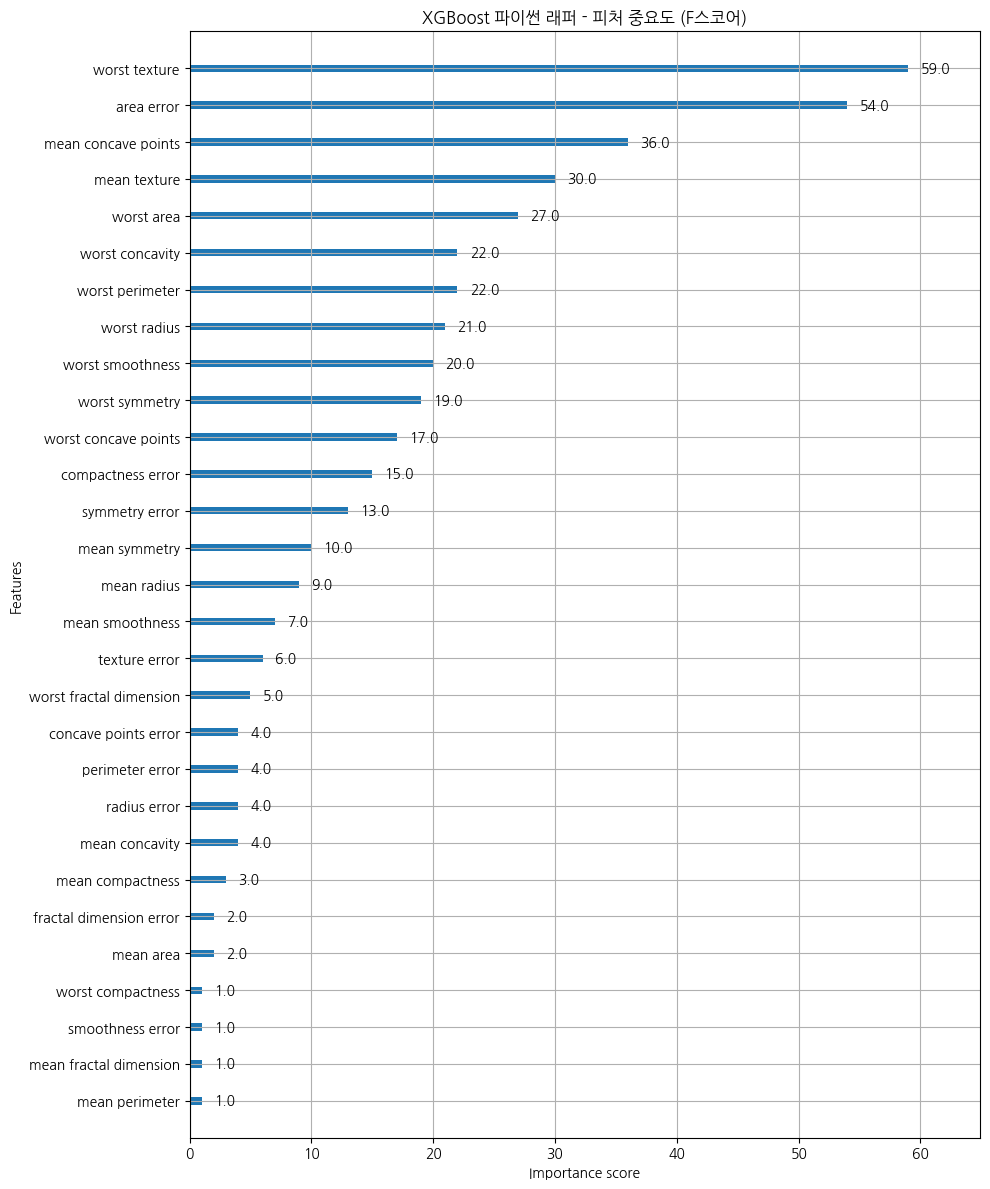

In [9]:
#피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_wrapper1, ax=ax)
plt.title('XGBoost 파이썬 래퍼 - 피처 중요도 (F스코어)')
plt.tight_layout()
plt.show()

### LightGBM

In [10]:
from lightgbm import LGBMClassifier, plot_importance
from lightgbm.callback import early_stopping

lgbm_wrapper = LGBMClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    objective = 'binary',
    min_child_samples = 5 #기본값 20->줄이면 더 잘게 분기 가능
)
evals = [(X_tr,y_tr),(X_val,y_val)]
lgbm_wrapper.fit(X_tr,y_tr,
                 eval_set=evals,
                 eval_metric='logloss',
                 callbacks=[early_stopping(stopping_rounds=50, verbose=True)])

preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test, preds, pred_proba, 'LightGBM (Early stopping=50)')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

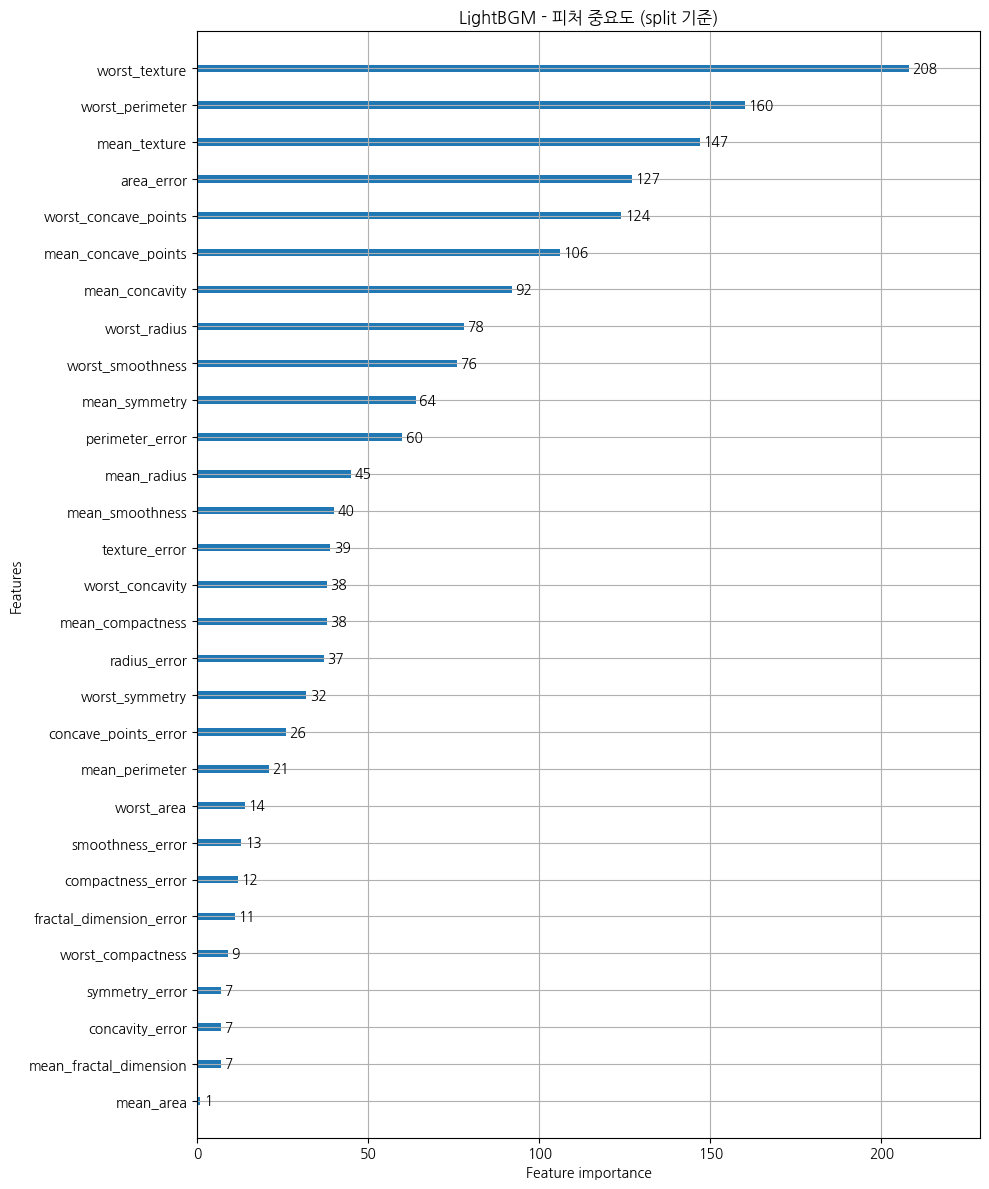

In [11]:
#피처 중요도 시각화
fig, ax = plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper, ax=ax)
plt.title('LightBGM - 피처 중요도 (split 기준)')
plt.tight_layout()
plt.show()

### CatBoost

In [12]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [13]:
import catboost
print('CatBoost 버전:',catboost.__version__)

CatBoost 버전: 1.2.10


In [14]:
from catboost import CatBoostClassifier, Pool

#Pool: CatBoost 전용 데이터 구조
train_pool = Pool(data = X_train, label = y_train, cat_features=[]) #범주형 피처
val_pool = Pool(data = X_val, label = y_val, cat_features=[])
test_pool = Pool(data = X_test, label = y_test, cat_features=[])

print(f'train_pool 크기: {train_pool.num_row()} 행 X {train_pool.num_col()} 피처')
print(f'test_pool 크기: {test_pool.num_row()} 행 X {test_pool.num_col()} 피처')

train_pool 크기: 455 행 X 30 피처
test_pool 크기: 114 행 X 30 피처


In [15]:
cat_clf = CatBoostClassifier(
    iterations = 500, #부스팅 라운드 수
    learning_rate = 0.05,
    depth = 6, #대칭 트리 깊이(기본값 6 권장)
    loss_function = 'Logloss',
    eval_metric = 'Accuracy',
    random_seed = 42,
    verbose = 100 #100라운드 마다 학습 상황 출력
)

cat_clf.fit(train_pool, eval_set=val_pool,early_stopping_rounds = 50, plot=False)
print(f'\n학습 완료, 최적 라운드: {cat_clf.best_iteration_}')
print(f'최적 라운드 검증 정확도: {cat_clf.best_score_["validation"]["Accuracy"]:.4f}')

cat_preds = cat_clf.predict(test_pool)
cat_pred_proba = cat_clf.predict_proba(test_pool)[:,1]
get_clf_eval(y_test, cat_preds, cat_pred_proba, 'CatBoost (기본)')

0:	learn: 0.9582418	test: 0.9347826	best: 0.9347826 (0)	total: 52.9ms	remaining: 26.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 37

Shrink model to first 38 iterations.

학습 완료, 최적 라운드: 37
최적 라운드 검증 정확도: 1.0000
=== CatBoost (기본) ===
오차 행렬
[[34  3]
 [ 1 76]]
정확도:0.9649 | 정밀도:0.9620|재현율:0.9870 | F1:0.9744 | AUC:0.9958


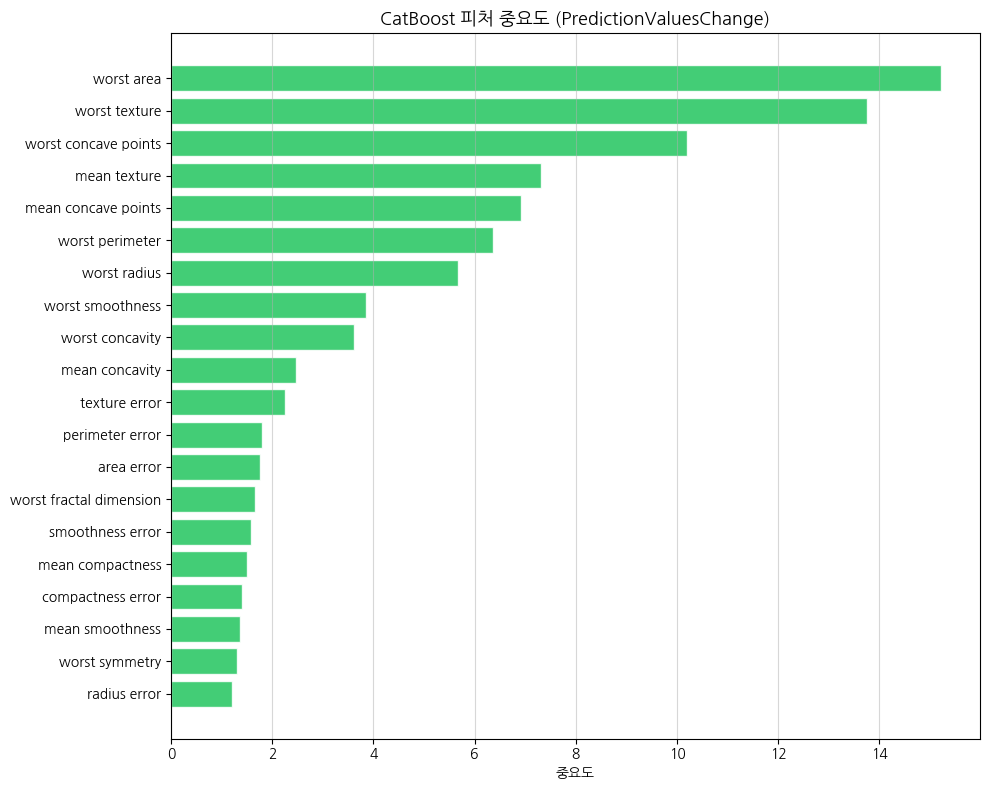

In [16]:
#피처 중요도 시각화
feature_importance = cat_clf.get_feature_importance(
    data = test_pool,
    type = 'PredictionValuesChange' #피처 제거시 예측값 변화량
)
feature_names = X_train.columns.tolist()
sorted_idx = np.argsort(feature_importance)
top_n=20

fig, ax = plt.subplots(figsize=(10,8))
ax.barh(
    [feature_names[i] for i in sorted_idx[-top_n:]],
    feature_importance[sorted_idx[-top_n:]],
    color = '#22c55e',alpha = 0.85, edgecolor='white'
)
ax.set_title('CatBoost 피처 중요도 (PredictionValuesChange)',fontsize=13)
ax.set_xlabel('중요도')
ax.grid(axis='x',alpha=0.5)
plt.tight_layout()
plt.show()

### XGBoost vs LightGBM vs CatBoost 최종 비교

In [17]:
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping as XGBEarlyStopping

from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping as lgbm_early_stopping

from catboost import CatBoostClassifier, Pool

import time

In [18]:
results = {}
#XGBoost
t0 = time.time()
xgb_cmp = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    eval_metric = 'logloss',
    random_state = 42,
    callbacks = [XGBEarlyStopping(rounds=50, save_best=True, maximize=False)],
)
xgb_cmp.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    verbose = False
)
t_xgb = time.time() - t0 # Corrected: t0 should be reset or used consistently
p_xgb = xgb_cmp.predict(X_test)
pp_xgb = xgb_cmp.predict_proba(X_test)[:, 1]
results['XGBoost'] = {
    '정확도' : accuracy_score(y_test, p_xgb),
    'AUC' : roc_auc_score(y_test, pp_xgb),
    '학습시간' : t_xgb,
    '최적라운드' : xgb_cmp.best_iteration,
}
#LightGBM
t0 = time.time()
lgbm_cmp = LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    num_leaves = 31,
    random_state = 42,
    verbose = -1,
)
lgbm_cmp.fit(
    X_tr, y_tr,
    eval_set = [(X_val, y_val)],
    eval_metric = 'logloss', # Corrected: 'eval_mertic' to 'eval_metric'
    callbacks = [lgbm_early_stopping(stopping_rounds=50, verbose=True)]
)
t_lgbm = time.time() - t0
p_lgbm = lgbm_cmp.predict(X_test)
pp_lgbm = lgbm_cmp.predict_proba(X_test)[:, 1]
results['LightBGM'] = {
    '정확도' : accuracy_score(y_test, p_lgbm),
    'AUC' : roc_auc_score(y_test, pp_lgbm),
    '학습시간' : t_lgbm,
    '최적라운드' : lgbm_cmp.best_iteration_,
}
#CatBoost
cat_cols = [] #범주형 컬럼명 리스트['컬럼명','컬럼명']
cat_features_idx = [X_train.columns.tolist().index(c) for c in cat_cols]

train_pool = Pool(X_tr, y_tr, cat_features=cat_features_idx)
val_pool = Pool(X_val, y_val, cat_features=cat_features_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_features_idx)

t0 = time.time()
cat_cmp = CatBoostClassifier(
    iterations = 500,
    learning_rate = 0.05,
    depth = 6,
    loss_function = 'Logloss',
    random_seed = 42,
    verbose = False,
)
cat_cmp.fit(
    train_pool,
    eval_set = val_pool,
    early_stopping_rounds = 50,
)
t_cat = time.time() - t0
p_cat = cat_cmp.predict(test_pool)
pp_cat = cat_cmp.predict_proba(test_pool)[:, 1]
results['CatBoost'] = {
    '정확도' : accuracy_score(y_test, p_cat),
    'AUC' : roc_auc_score(y_test, pp_cat),
    '학습시간': t_cat,
    '최적라운드': cat_cmp.best_iteration_
}

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[61]	valid_0's binary_logloss: 0.260236


In [19]:
cmp_df = pd.DataFrame(results).T
cmp_df['정확도'] = cmp_df['정확도'].round(4)
cmp_df['AUC'] = cmp_df['AUC'].round(4)
cmp_df['학습시간'] = cmp_df['학습시간'].apply(lambda x: f'{x:.2f}초')
cmp_df['최적라운드'] = cmp_df['최적라운드'].astype(int)
print('===3종GBM 비교(위스콘신 유방암)===')
display(cmp_df)

===3종GBM 비교(위스콘신 유방암)===


,정확도,AUC,학습시간,최적라운드
XGBoost,0.9737,0.9947,0.50초,104
LightBGM,0.9561,0.9877,0.09초,61
CatBoost,0.9298,0.9933,2.81초,108


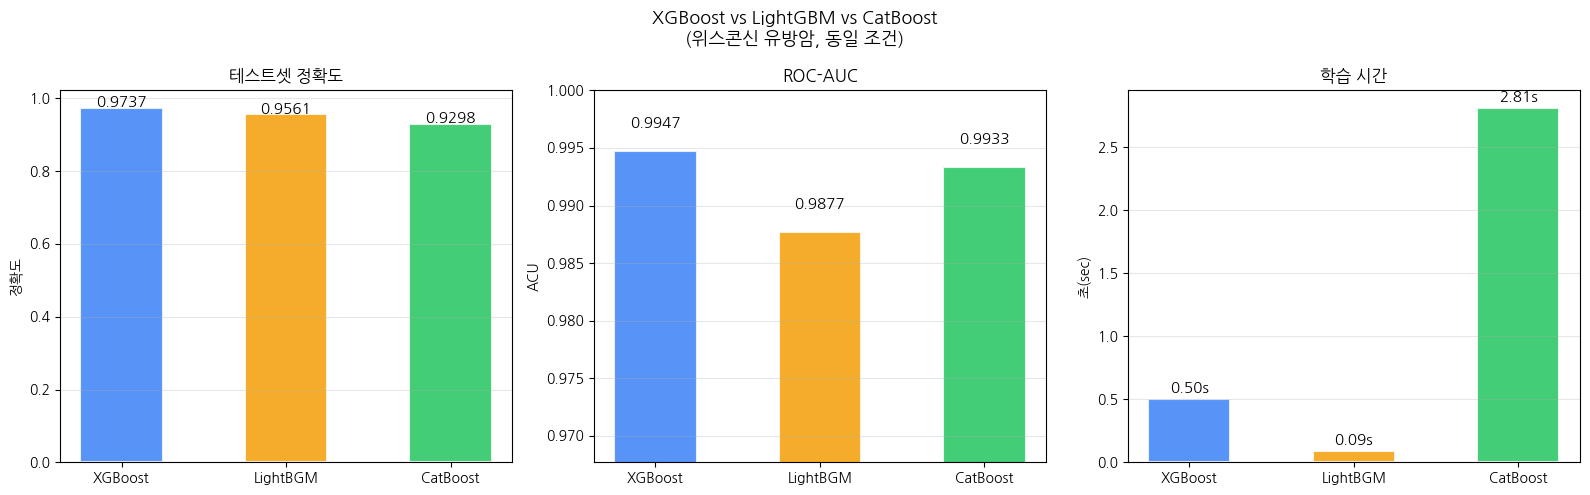

In [20]:
#시각화: 4개 지표 동시 비교
models = list(results.keys())
colors = ['#3b82f6','#f59e06','#22c55e']

acc = [results[m]['정확도'] for m in models]
auc = [results[m]['AUC'] for m in models]
times = [results[m]['학습시간'] for m in models]
rounds = [results[m]['최적라운드'] for m in models]

fig, axes = plt.subplots(1,3,figsize=(16,5))

#정확도 비교
bars0=axes[0].bar(models, acc, color=colors, alpha=0.85, width=0.5, edgecolor='white',linewidth=1.5)
axes[1].set_ylim(min(acc)-0.02,1.0)
axes[0].set_ylabel('정확도')
axes[0].set_title('테스트셋 정확도',fontsize=12)
axes[0].grid(axis='y',alpha=0.3)
for bar, v in zip(bars0, acc):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}',ha='center', fontsize=11,fontweight='bold')
#AUC 비교
bars1=axes[1].bar(models, auc, color=colors, alpha=0.85, width=0.5, edgecolor='white',linewidth=1.5)
axes[1].set_ylim(min(auc)-0.02,1.0)
axes[1].set_ylabel('ACU')
axes[1].set_title('ROC-AUC',fontsize=12)
axes[1].grid(axis='y',alpha=0.3)
for bar, v in zip(bars1, auc):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{v:.4f}',ha='center', fontsize=11,fontweight='bold')
#학습 시간 비교
bars2=axes[2].bar(models, times, color=colors, alpha=0.85, width=0.5, edgecolor='white',linewidth=1.5)
axes[2].set_ylabel('초(sec)')
axes[2].set_title('학습 시간',fontsize=12)
axes[2].grid(axis='y',alpha=0.3)
for bar, v in zip(bars2, times):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{v:.2f}s',ha='center', fontsize=11,fontweight='bold')
plt.suptitle('XGBoost vs LightGBM vs CatBoost\n(위스콘신 유방암, 동일 조건)',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 하이퍼파라미터 튜닝 방법 - Optuna

In [21]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.0 MB/s eta 0:00:00


In [22]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(optuna.__version__)

4.8.0


In [23]:
from sklearn.model_selection import cross_val_score

In [24]:
#목적 함수 정의
def optuna_objective(trial):
  #각 하이퍼파라미터의 탐색 범위를 정의
  n_estimators = trial.suggest_int('n_estimators',100,500) #트리 개수:100~500 정수 중에서 선택
  max_depth = trial.suggest_int('max_depth',3,100) #트리의 최대 깊이
  learning_rate = trial.suggest_float('learning_rate',0.01,0.3,log=True) #학습률:0.01~0.3 실수 중에서 로그 스케일로 선택
  min_child_weight = trial.suggest_int('min_child_weight',1,5) #자식노드 최소 샘플 수
  subsample = trial.suggest_float('subsample',0.6,1.0) #샘플 데이터의 비율
  colsample_bytree = trial.suggest_float('colsample_bytree',0.6,1.0) #피처(컬럼) 데이터의 비율
  reg_alpha = trial.suggest_float('reg_alpha',1e-8,1.0,log=True) #1e-8는 0.00000001 (+일 경우 10000000)
  reg_lambda = trial.suggest_float('reg_lambda',1e-8,1.0,log=True)
  #L1 정규화(Lasso Regularization) : 가중치들의 절대값 합을 벌칙 항으로 추가하여 중요하지 않은 피처의 가중치를 0으로 만들고 피처 선택 효과를 가진다.
  #L2 정규화(Ridge Regularization) : 가중치들의 제곱 합을 항으로 추가하여 가중치를 0에 가깝게 축소, 다중 공선성 문제에 안정적 모델을 만든다.
    #다중 공선성 문제 : 독립 변수들 사이에 강한 상관관계를 나타내는 상태

  #모델 생성 및 교차 검증 : 샘플링된 하이퍼파라미터로 모델을 초기화
  xgb_clf = XGBClassifier(
      n_estimators = n_estimators,
      max_depth = max_depth,
      learning_rate = learning_rate,
      min_child_weight = min_child_weight,
      subsample = subsample,
      colsample_bytree = colsample_bytree,
      reg_alpha = reg_alpha,
      reg_lambda = reg_lambda,
      eval_metric = 'logloss',
      random_state = 42
  )
  accuracy = cross_val_score(xgb_clf, X_train, y_train, scoring = 'accuracy', cv=5, n_jobs=-1)
  return accuracy.mean() #5개 폴드의 평균 정확도를 반환

### Optuna 핵심 개념
1. Study : 최적화 세션 전체, 여러 번의 trial(시도)을 묶는 단위
2. Trial : 한 번의 하이퍼 파라미터 조합 시도
3. Objective:
- Optuna가 각 trial마다 호출하는 목적 함수
- 이 함수는 주어진 trial 객체로부터 하이퍼파라미터를 샘플링하고,
- 해당 하이퍼 파라미터로 XGBoost 모델을 학습한 후 교차 검증 정확도(평가 지표)를 반환.
- 반환값은 study의 direction('maximize')에 따라 최대화

In [25]:
#Study 생성 및 최적화 실행
study = optuna.create_study(
    direction = 'maximize', #목적 함수(정확도)를 최대화하는 방향으로 최적화를 수행, (반대는 minimize)
    study_name = 'XGBoost튜닝',
    sampler = optuna.samplers.TPESampler(seed=42)
)
#탐색 알고리즘으로 TPE(Tree-structured Parzen Estimator)를 사용. 이전 Trial 결과를 바탕으로 다음 Trial의 하이퍼 파라미터 제안
import time
start = time.time()

#Study의 optimize 메서드를 호출하여 하이퍼파라미터 최적화를 실행
study.optimize(
    optuna_objective,
    n_trials = 50,
    show_progress_bar = True
)
elapsed = time.time() - start
print(f'\n탐색 완료. 소요시간: {elapsed:.1f}초')
print(f'총 trial 수: {len(study.trials)}회')

print(f"\n최적 CV 정확도: {study.best_trial.value:.4f}")
print("최적 하이퍼파라미터:")
for k,v in study.best_params.items():
  if isinstance(v, float):
    print(f'{k}: {v:.6f}')
  else:
    print(f'{k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


탐색 완료. 소요시간: 42.6초
총 trial 수: 50회

최적 CV 정확도: 0.9692
최적 하이퍼파라미터:
n_estimators: 157
max_depth: 60
learning_rate: 0.091453
min_child_weight: 5
subsample: 0.742666
colsample_bytree: 0.642958
reg_alpha: 0.126961
reg_lambda: 0.000000


In [26]:
best_params = study.best_params

xgb_optuna = XGBClassifier(
    **best_params, #딕셔너리 언패킹으로 파라미터 일괄 전달
    eval_metric = 'logloss',
    random_state = 42,
    early_stopping_rounds = 50
)
evals = [(X_tr,y_tr),(X_val,y_val)]
xgb_optuna.fit(X_tr,y_tr,eval_set = evals,verbose=True)
optuna_preds = xgb_optuna.predict(X_test)
optuna_pred_proba = xgb_optuna.predict_proba(X_test)[:,1]

get_clf_eval(y_test,optuna_preds,optuna_pred_proba,'Optuna 최적화 XGBoost')

[0]	validation_0-logloss:0.59646	validation_1-logloss:0.60986
[1]	validation_0-logloss:0.53399	validation_1-logloss:0.55618
[2]	validation_0-logloss:0.48492	validation_1-logloss:0.52340
[3]	validation_0-logloss:0.43984	validation_1-logloss:0.49421
[4]	validation_0-logloss:0.40409	validation_1-logloss:0.47109
[5]	validation_0-logloss:0.37060	validation_1-logloss:0.44415
[6]	validation_0-logloss:0.34219	validation_1-logloss:0.42294
[7]	validation_0-logloss:0.31660	validation_1-logloss:0.40465
[8]	validation_0-logloss:0.29387	validation_1-logloss:0.39201
[9]	validation_0-logloss:0.27351	validation_1-logloss:0.37848
[10]	validation_0-logloss:0.25449	validation_1-logloss:0.36981
[11]	validation_0-logloss:0.23886	validation_1-logloss:0.36250
[12]	validation_0-logloss:0.22301	validation_1-logloss:0.35104
[13]	validation_0-logloss:0.20991	validation_1-logloss:0.34096
[14]	validation_0-logloss:0.19746	validation_1-logloss:0.33486
[15]	validation_0-logloss:0.18701	validation_1-logloss:0.32578
[1

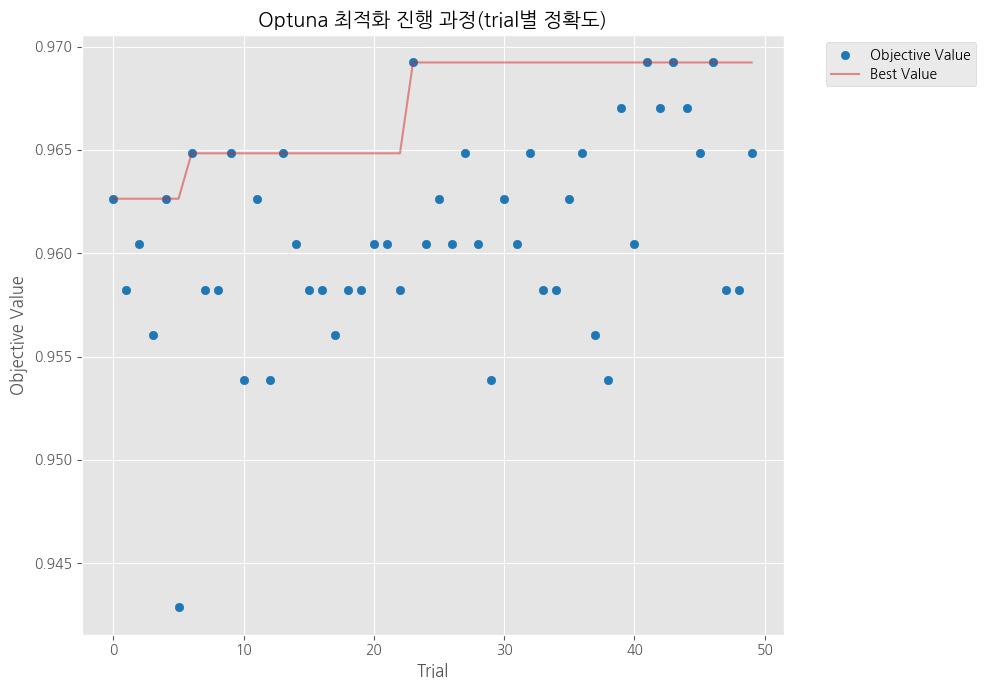

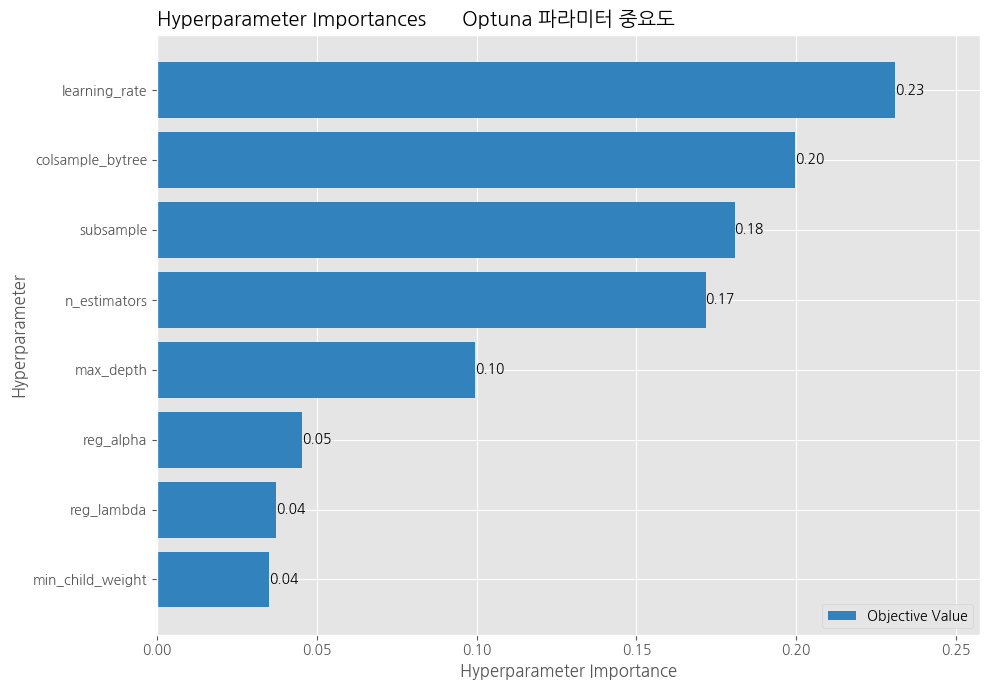


상위 10개 trial:


,number,value,n_estimators,max_depth,learning_rate
41,41,0.9692,157,60,0.0915
23,23,0.9692,313,12,0.0693
46,46,0.9692,125,56,0.1356
43,43,0.9692,163,62,0.0901
39,39,0.9670,161,46,0.0847
42,42,0.9670,181,63,0.0895
44,44,0.9670,152,62,0.0897
13,13,0.9648,318,6,0.0612
6,6,0.9648,319,21,0.2705
9,9,0.9648,102,82,0.1107


In [27]:
#Optuna 내장 시각화 1: 최적화 과정(목적 함수 값 변화)
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
fig.get_figure().set_size_inches(10,7)
plt.title('Optuna 최적화 진행 과정(trial별 정확도)')
plt.tight_layout()
plt.show()

#Optuna 내장 시각화 2: 하이퍼 파라미터 중요도
fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
fig2.get_figure().set_size_inches(10,7)
plt.title('Optuna 파라미터 중요도')
plt.tight_layout()
plt.show()

#상위 10개 trial 결과 DataFrame으로 확인
trial_df = study.trials_dataframe() #모든 trial을 DataFrame으로 변환
trial_df.columns = [c.replace('params_','')for c in trial_df.columns]
top10_optuna = (trial_df.sort_values('value',ascending=False).head(10)[['number','value','n_estimators','max_depth','learning_rate']])
print('\n상위 10개 trial:')
display(top10_optuna.round(4))